### ***SmartCart Customer Puchase Prediction System***

- ***This project builds an **AI-powered Customer Segmentation System** for **SmartCart** using **Unsupervised Machine Learning**. The objective is to group customers with similar purchasing behavior, engagement, and loyalty patterns into meaningful clusters.***

- ***By analyzing **2240 customer records** with **22 features**, the system helps identify high-value customers, detect churn-prone users, and support personalized marketing strategies. The insights generated enable better customer retention, improved marketing efficiency, and data-driven business decisions.***

**Algorithms:** K-Means, Hierarchical Clustering, DBSCAN, and GMM.

In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 

df = pd.read_csv("../data/smartcart_data.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [2]:
df.shape

(2240, 22)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [4]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.009375,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.096391,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000


In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

#### ***Data Preprocessing***

In [6]:
# Handling Missing Value

df["Income"] = df["Income"].fillna(df["Income"].median())

#### ***Feature Engineering***

In [7]:
df["Age"] = 2026 - df["Year_Birth"]

# Customer Joining Data
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)
refer_date = df["Dt_Customer"].max()

df["Customer_TenureDay"]  = (refer_date - df["Dt_Customer"]).dt.days

# Spending 
df["Total_Spent"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"]  + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

# Children Section 
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [8]:
# Education 
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [9]:
df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate", "PhD": "Postgraduate"
})

In [10]:
# MArtial Status 
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [11]:
df["Living_Partner"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_TenureDay,Total_Spent,Total_Children,Living_Partner
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [13]:
# remove unwanted columns 
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

drop_cols = cols+spending_cols
clean_df = df.drop(columns=drop_cols)

In [14]:
clean_df.shape

(2240, 15)

In [15]:
clean_df.sample(5)

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_TenureDay,Total_Spent,Total_Children,Living_Partner
1390,Postgraduate,53761.0,7,6,4,4,3,5,0,0,54,261,325,2,Partner
1282,Postgraduate,37633.0,49,2,1,0,3,9,0,0,69,647,38,2,Partner
1211,Graduate,65748.0,58,2,2,4,10,1,1,0,71,440,545,1,Partner
32,Graduate,40548.0,31,2,2,1,4,5,0,0,56,627,120,1,Partner
1969,Postgraduate,85738.0,41,1,3,6,11,1,0,0,48,157,1371,0,Partner


- ***Detecting Outliers***

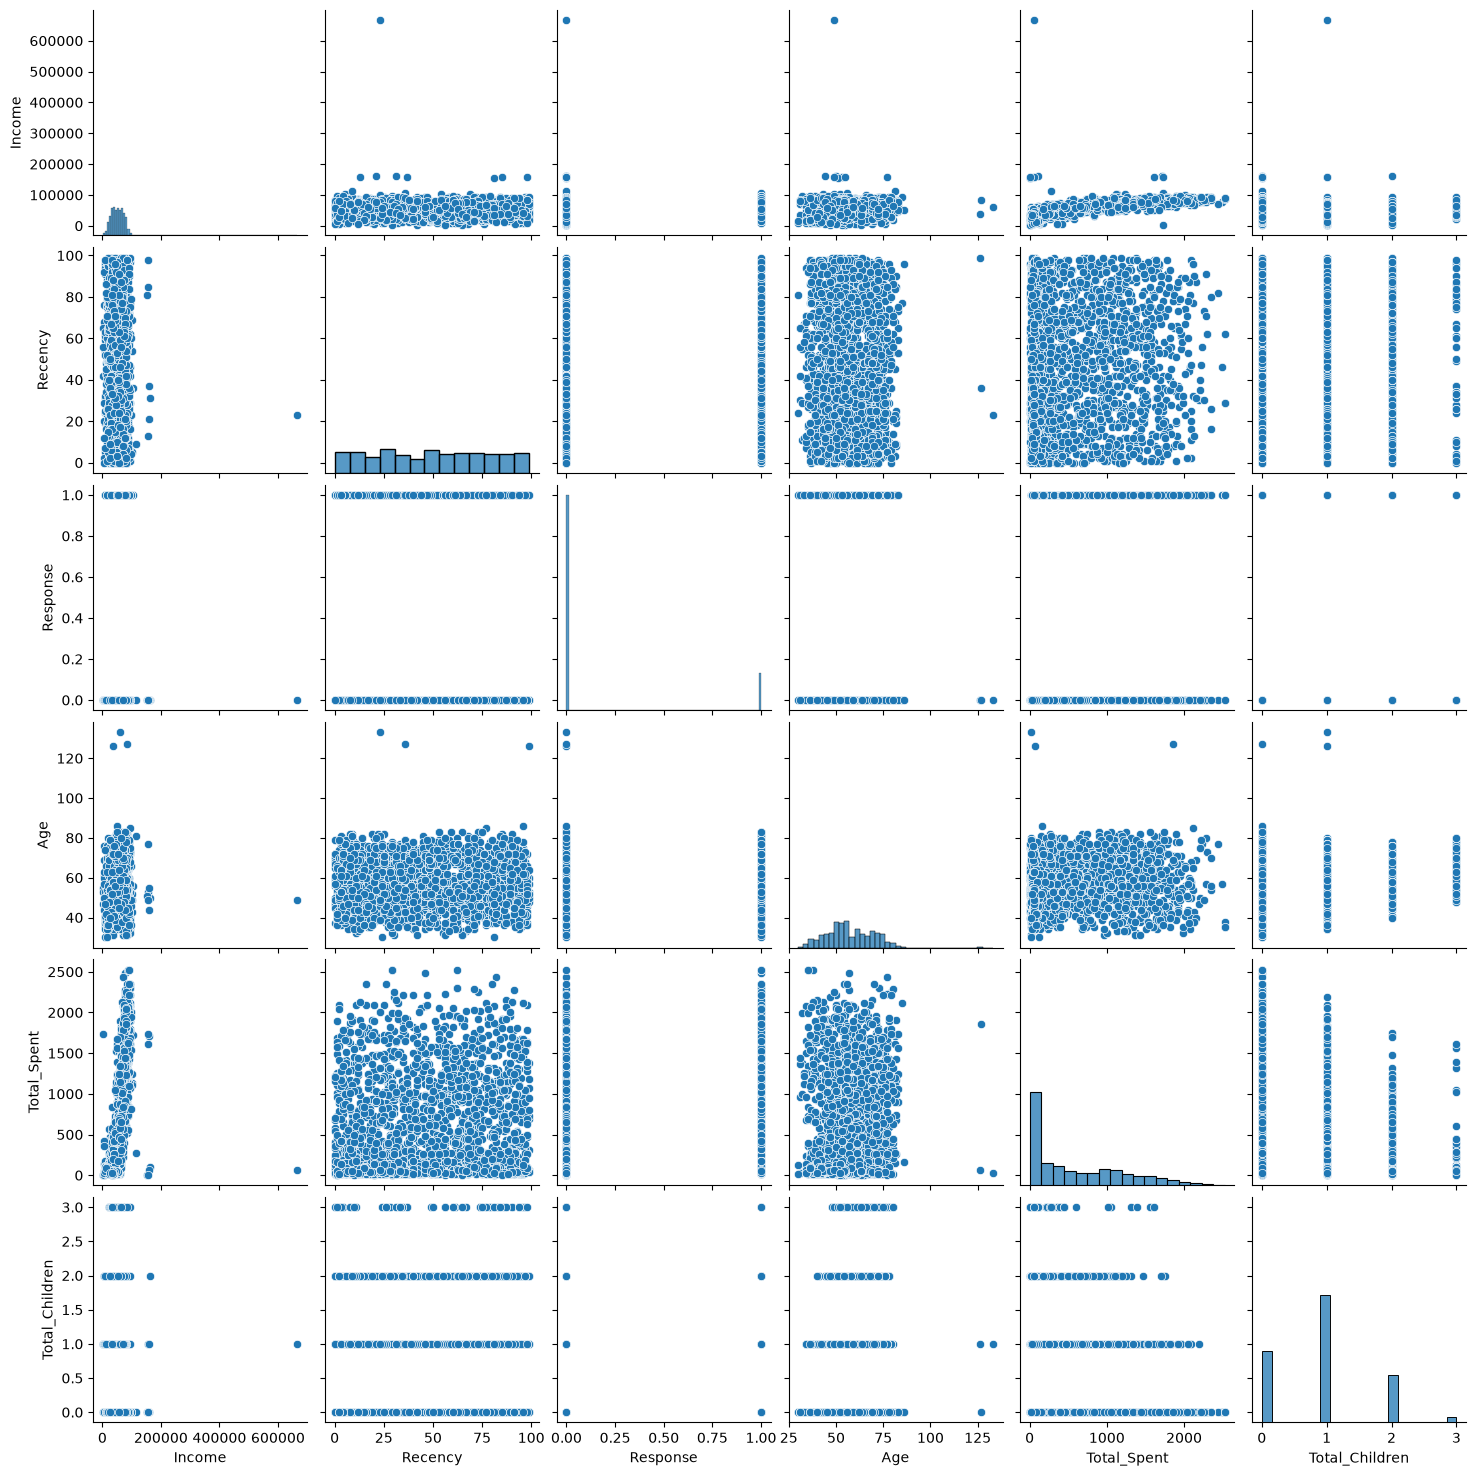

In [16]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spent", "Total_Children"]
sns.pairplot(clean_df[cols])

In [17]:
print(f"data with outliers:{len(clean_df)}")

clean_df = clean_df[(clean_df["Age"] < 95)]
clean_df = clean_df[(clean_df["Income"] < 600_000)]
print(f"data without outliers:{len(clean_df)}")

data with outliers:2240
data without outliers:2236


- ***See Realtionship Using Heatmap***

<Axes: >

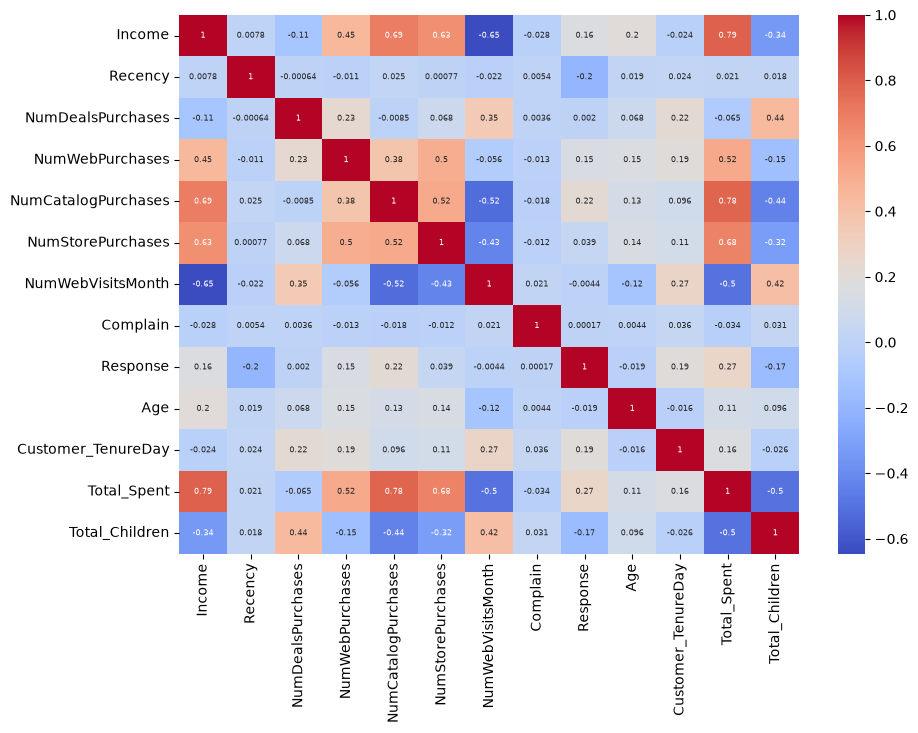

In [18]:
corr = clean_df.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm"
)

In [19]:
clean_df.sample(5)

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_TenureDay,Total_Spent,Total_Children,Living_Partner
1932,Postgraduate,21059.0,40,3,3,0,3,6,0,0,44,173,44,1,Partner
1976,Undergraduate,32632.0,32,2,4,4,8,5,0,0,63,696,576,0,Partner
1125,Graduate,39552.0,54,7,6,2,5,8,0,1,64,558,384,2,Alone
2080,Graduate,27803.0,40,2,3,0,4,8,0,0,53,672,176,1,Partner
478,Postgraduate,62010.0,93,4,6,2,7,5,0,0,54,614,530,1,Partner


- ***Encoding***

In [20]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 2236 entries, 0 to 2239
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2236 non-null   str    
 1   Income               2236 non-null   float64
 2   Recency              2236 non-null   int64  
 3   NumDealsPurchases    2236 non-null   int64  
 4   NumWebPurchases      2236 non-null   int64  
 5   NumCatalogPurchases  2236 non-null   int64  
 6   NumStorePurchases    2236 non-null   int64  
 7   NumWebVisitsMonth    2236 non-null   int64  
 8   Complain             2236 non-null   int64  
 9   Response             2236 non-null   int64  
 10  Age                  2236 non-null   int64  
 11  Customer_TenureDay   2236 non-null   int64  
 12  Total_Spent          2236 non-null   int64  
 13  Total_Children       2236 non-null   int64  
 14  Living_Partner       2236 non-null   str    
dtypes: float64(1), int64(12), str(2)
memory usage: 279.5 K

In [21]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
cat_col = ["Education","Living_Partner"]
encoded_cols = encoder.fit_transform(clean_df[cat_col])

In [22]:
encoded_df = pd.DataFrame(encoded_cols.toarray(), columns=encoder.get_feature_names_out(cat_col), index=clean_df.index)

In [23]:
encoded_df = pd.concat([clean_df.drop(columns=cat_col),encoded_df], axis=1)
encoded_df.sample(7)

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_TenureDay,Total_Spent,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_Partner_Alone,Living_Partner_Partner
1671,86610.0,66,1,5,6,6,2,0,0,75,297,1603,0,1.0,0.0,0.0,0.0,1.0
527,50353.0,72,1,4,4,6,3,0,0,49,21,442,0,0.0,1.0,0.0,0.0,1.0
203,102160.0,54,0,7,9,10,4,0,1,49,604,1240,0,0.0,1.0,0.0,0.0,1.0
1089,71691.0,0,1,4,7,5,2,0,1,68,104,1192,0,0.0,1.0,0.0,1.0,0.0
374,38578.0,2,3,3,0,3,8,0,1,54,372,73,2,0.0,1.0,0.0,1.0,0.0
1734,75342.0,38,1,5,2,10,4,0,0,68,419,563,1,0.0,0.0,1.0,1.0,0.0
311,22574.0,28,2,2,0,3,7,0,0,59,244,37,3,1.0,0.0,0.0,0.0,1.0


In [24]:
encoded_df.shape

(2236, 18)

- ***Scaling***

In [25]:
from sklearn.preprocessing import StandardScaler
X = encoded_df

scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

- ***PCA***

In [26]:
from sklearn.decomposition import PCA  
pca = PCA(n_components=3)
x_pca = pca.fit_transform(x_scaled)

In [27]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

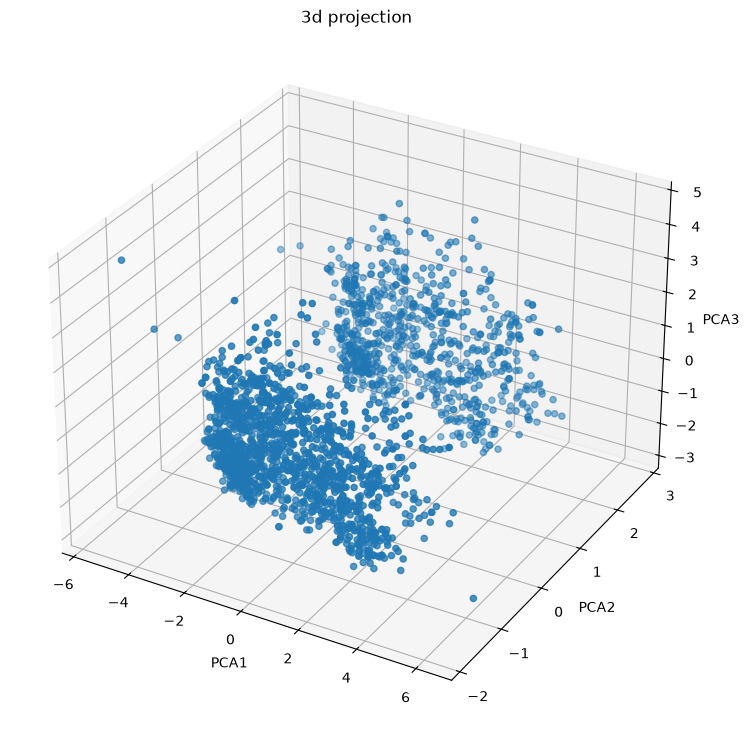

In [28]:
## Plot Graph 
fig = plt.figure(figsize=(17,9))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

#### ***Analyse value of K***
   - Elbow Mwthod 
   - Silhoutte Score

In [29]:
# Using Elbow Method 
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmean = KMeans(n_clusters=k,random_state=42)
    kmean.fit_predict(x_pca)
    wcss.append(kmean.inertia_)

Text(0, 0.5, 'WCSS')

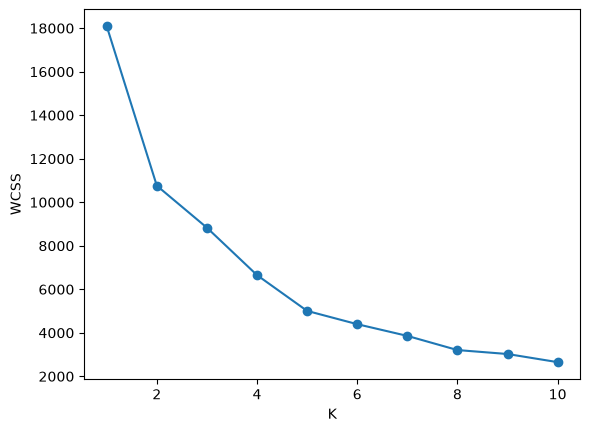

In [30]:
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

In [31]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow
print(f"Best Value of K: {optimal_k}")

Best Value of K: 4


Text(0, 0.5, 'silhoutte score')

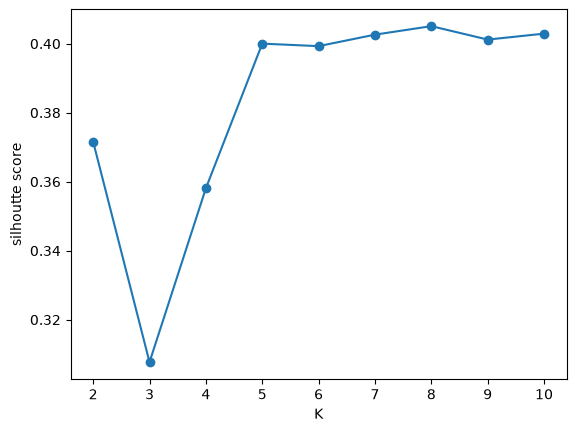

In [32]:
## Using Silhoutte Score
from sklearn.metrics import silhouette_score
scores = []

for k in range(2,11):
    kmean = KMeans(n_clusters=k,random_state=42)
    labels = kmean.fit_predict(x_pca)
    score = silhouette_score(x_pca,labels)
    scores.append(score)

# Plot Graph  
plt.plot(range(2,11),scores,marker='o')
plt.xlabel("K")
plt.ylabel("silhoutte score")

Text(0, 0.5, 'SS')

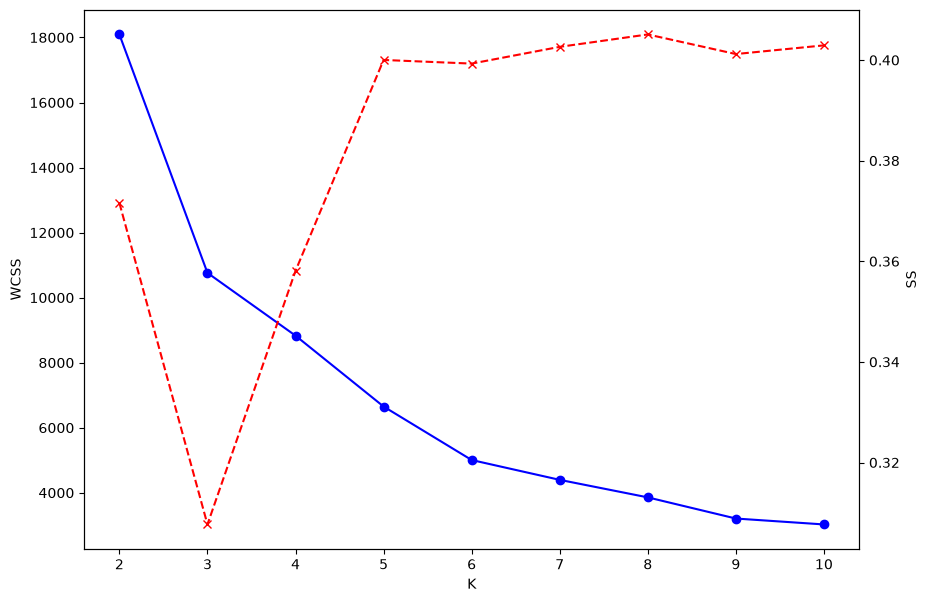

In [33]:
# Cobined Plot 
k_range = range(2,11)
fig,ax1 = plt.subplots(figsize=(10,7))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")
ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

- Apply Clustering 

In [34]:
kmean = KMeans(n_clusters=4,random_state=42)
labels = kmean.fit_predict(x_pca)

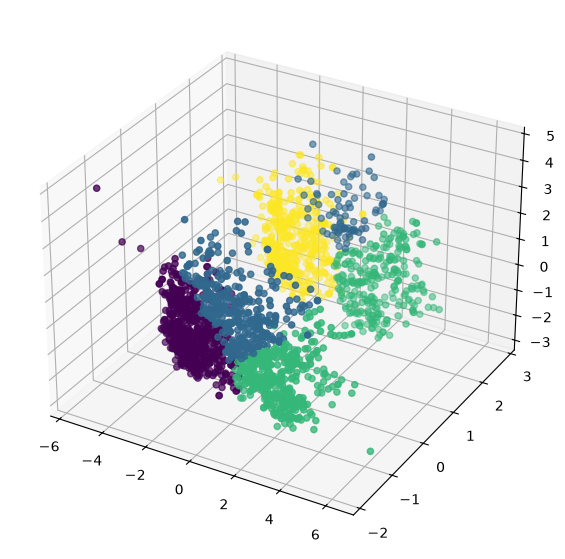

In [35]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels)

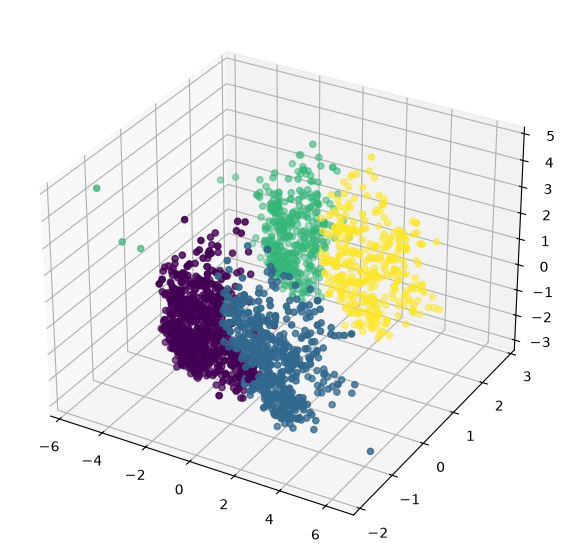

In [36]:
## Apply Agglomerative Clustering 
from sklearn.cluster import  AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=4,linkage="ward")
label = agg.fit_predict(x_pca)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=label)

In [37]:
X["cluster"] = labels
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_TenureDay,Total_Spent,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_Partner_Alone,Living_Partner_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,2
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,3
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,2
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,1


<Axes: xlabel='cluster', ylabel='count'>

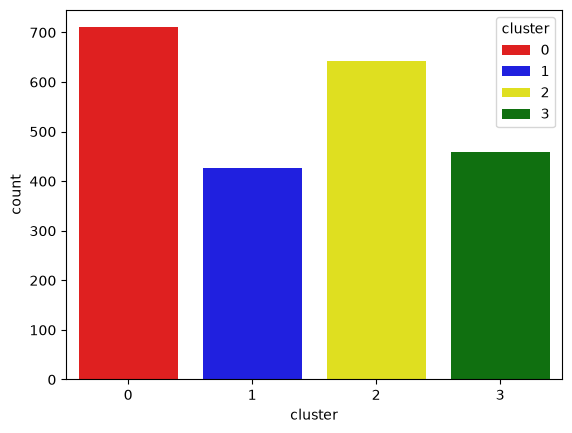

In [38]:
palet = ["red", "blue", "yellow", "green"]
sns.countplot(x=X["cluster"], palette=palet, hue=X["cluster"])

<Axes: xlabel='Total_Spent', ylabel='Income'>

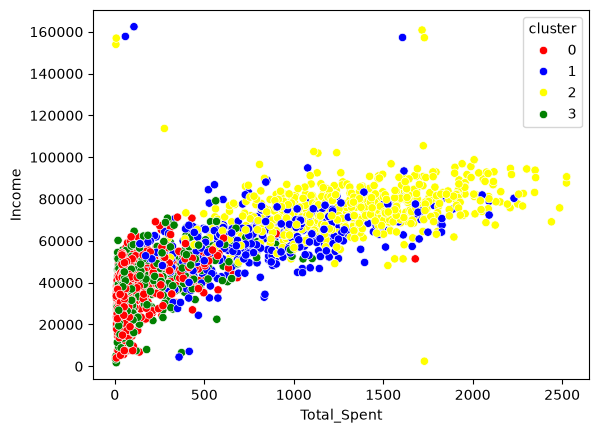

In [39]:
# Income & Spending 
sns.scatterplot(x=X["Total_Spent"],y=X["Income"],hue=X["cluster"],palette=palet)

In [40]:
# Cluster Summary
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        35604.642254  49.688732           2.176056         2.411268   
1        59857.395540  48.335681           3.645540         6.323944   
2        74671.218847  49.767913           1.510903         5.356698   
3        38097.327511  48.041485           2.473799         2.827511   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.605634           3.494366           6.481690  0.011268   
1                   3.476526           7.600939           5.577465  0.004695   
2                   5.665109           8.559190           3.021807  0.007788   
3                   0.888646           3.810044           6.495633  0.010917   

         Response        Age  Customer_TenureDay  Total_Spent  Total_Children  \
clust

In [41]:
X.columns

Index(['Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_TenureDay', 'Total_Spent',
       'Total_Children', 'Education_Graduate', 'Education_Postgraduate',
       'Education_Undergraduate', 'Living_Partner_Alone',
       'Living_Partner_Partner', 'cluster'],
      dtype='str')

In [42]:
## Make Pipeline 
import joblib
export_data = {
    'pca_model': pca,          
    'cluster_labels': label,   
    'agg_model': agg           
}

# save to disk
joblib.dump(export_data, '../../model/pipeline.pkl')

['../../model/pipeline.pkl']